In [ ]:
suppressPackageStartupMessages({
    library(ggplot2)
    library(Seurat)
    library(dplyr)
    library(tidyr)
    library(tibble)
    library(stringr)
    library(dittoSeq)
    library(future)
    library(data.table)
    plan("multicore", workers = 12)
    options(future.globals.maxSize = 1000 * 1024^5)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”


In [ ]:
myeloid <- readRDS('/projects/0/einf2548/cruiz/dmg/data/myeloid_rna.rds')
myeloid

An object of class Seurat 
19248 features across 60672 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
MP_list = readRDS('data/robust_NMF_programs_myeloid_nomt_noribo.rds')

In [ ]:
MP_list = as.data.frame(MP_list) %>% select(c('MP_3','MP_11'))

In [ ]:
for (i in 1:ncol(MP_list)) {
  gene_set <- as.data.frame(MP_list)[[i]]
  myeloid <- UCell::AddModuleScore_UCell(
    obj = myeloid,
    features = list(gene_set),
    ncores = 16,
    name = colnames(MP_list)[i]
  )
}

In [ ]:
myeloid@meta.data

,nCount_RNA,nFeature_RNA,nCount_RAW,nFeature_RAW,DF.class,DF.score,scDblFinder.class,scDblFinder.score,ID,SampleID,⋯,MP_4_1,MP_10_1,MP_7_1,MP_2_1,MP_8_1,MP_9_1,MP_Assignment,Material,signature_1MP_3,signature_1MP_11
,<dbl>,<int>,<dbl>,<int>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
BT042_PD_TGCGATAAGCCATCCG-1,4960,2065,4994,2080,Singlet,0.10909091,Singlet,0.76924258,T18-90532,BT042_PD,⋯,-0.00236428,-0.13057575,0.064428696,0.03415157,0.11490886,-0.072765798,MP8,nuclei,0.12080000,0.07240000
BT042_PD_GAATAGAGTTTATGCG-1,4726,2219,4867,2231,Singlet,0.07272727,Singlet,0.24659014,T18-90532,BT042_PD,⋯,0.03998572,-0.17807608,-0.073085107,0.18685520,0.26097250,-0.085841434,MP8,nuclei,0.12328000,0.08024667
BT042_PD_CCTGCATAGGTCACAG-1,4652,1813,4668,1824,Singlet,0.12727273,Singlet,0.08938396,T18-90532,BT042_PD,⋯,-0.14208201,-0.22154835,0.115023802,-0.45820713,0.16574633,0.105209994,MP8,nuclei,0.27742000,0.08321333
BT042_PD_CGGAGAACAACTGCTA-1,4820,2178,4903,2192,Singlet,0.14545455,Doublet,0.99548411,T18-90532,BT042_PD,⋯,0.02837985,-0.06634642,0.010894763,-0.15444584,0.38456945,-0.042155165,MP8,nuclei,0.13285333,0.06910000
BT042_PD_AGGGCTCCAACTCGTA-1,4537,1881,4567,1899,Singlet,0.09090909,Singlet,0.47738504,T18-90532,BT042_PD,⋯,0.21526037,-0.06344517,-0.028994205,-0.26797151,0.17035060,-0.073958196,MP4,nuclei,0.13994667,0.10639333
BT042_PD_GAGGCCTCACAGACGA-1,4003,1859,4017,1870,Singlet,0.10909091,Singlet,0.39733049,T18-90532,BT042_PD,⋯,-0.09419071,-0.15958002,-0.014367484,-0.28721043,0.27144924,-0.084445836,MP8,nuclei,0.16294000,0.04140667
BT042_PD_ACACTGACATAATCCG-1,3750,1920,3805,1938,Singlet,0.10909091,Singlet,0.75327098,T18-90532,BT042_PD,⋯,-0.03831031,-0.09485660,-0.004028131,0.16793354,0.33054251,0.122673014,MP8,nuclei,0.14693333,0.06458000
BT042_PD_TTCACGCTCGAGTGAG-1,3620,1835,3644,1849,Singlet,0.12727273,Singlet,0.26683545,T18-90532,BT042_PD,⋯,-0.00676619,-0.20783224,0.117037765,0.08801238,0.33531913,0.060785265,MP8,nuclei,0.14264667,0.07678667
BT042_PD_ATGAGTCCAATCGCAT-1,3547,1914,3607,1928,Singlet,0.10909091,Singlet,0.51619869,T18-90532,BT042_PD,⋯,0.15557673,0.06482436,0.083166953,0.81102772,0.02285536,0.227025136,MP2,nuclei,0.49424000,0.18901333


In [ ]:
cluster_cols <- c("MP4" = "#00a69c",
                 "MP10"= '#26a9e0',
                 "MP7"="#343682",
                 "MP2"="#165884",
                 "MP8"="#95bbcd",
                 "MP9"="#7b7dba",
                  "unresolved"="#ffffff"
                 )

In [ ]:
myeloid <- subset(myeloid, MP_Assignment!='unresolved')
myeloid

An object of class Seurat 
19248 features across 59217 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

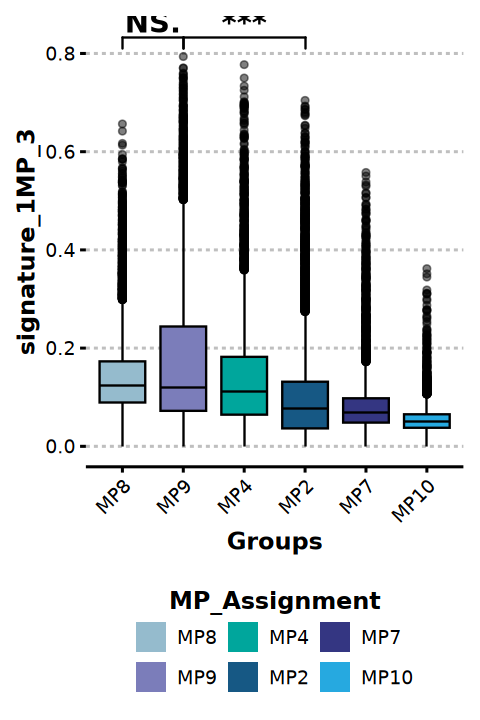

In [ ]:
options(repr.plot.height = 6, repr.plot.width = 4)
SCpubr::do_BoxPlot(sample = myeloid,
                   colors.use = cluster_cols,
                   feature = "signature_1MP_3",
                   group.by = "MP_Assignment",
                   use_test = TRUE,
                   comparisons = list(c("MP8", "MP9"),
                                      c("MP9", "MP2")),
                   map_signif_level = TRUE,
                   order = TRUE)

In [ ]:
ggsave('figures/boxplot_immunomodulatory_MP3_scoring.pdf', height = 6, width = 4.5)

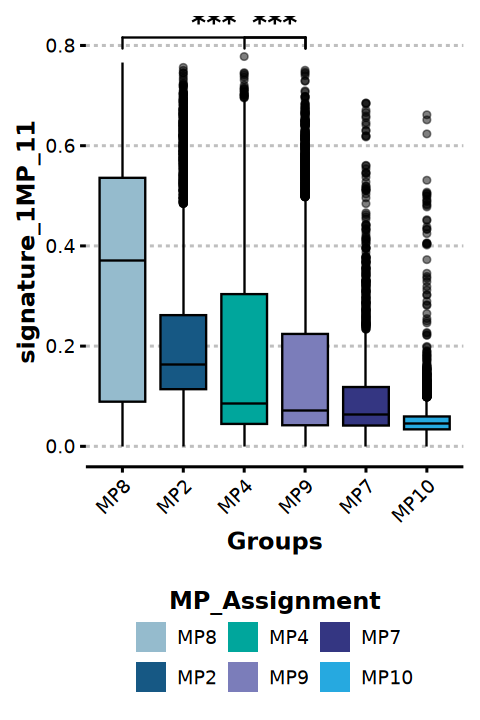

In [ ]:
options(repr.plot.height = 6, repr.plot.width = 4)
SCpubr::do_BoxPlot(sample = subset(myeloid, Material=='nuclei'),
                   colors.use = cluster_cols,
                   feature = "signature_1MP_11",
                   group.by = "MP_Assignment",
                   use_test = TRUE,
                    comparisons = list(c("MP8", "MP9"),
                                      c("MP9", "MP4")
                                      ),
                   map_signif_level = TRUE,
                   order = TRUE)

In [ ]:
ggsave('figures/boxplot_immunomodulatory_MP11_scoring.pdf', height = 6, width = 4.5)